In [1]:
# Cài đặt các thư viện cần thiết
!pip install gensim matplotlib scikit-learn numpy

  Obtaining dependency information for gensim from https://files.pythonhosted.org/packages/10/c3/7e22d6f7d88c4ea6a3a84481f00538252659d285713c3b7e2e1537b0e7e1/gensim-4.4.0-cp311-cp311-win_amd64.whl.metadata
  Using cached gensim-4.4.0-cp311-cp311-win_amd64.whl.metadata (8.6 kB)
  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/9f/71/34ddbd21f1da67c7a768146968b4d0220ee6831e4bcbad3e03dd3eae88b6/scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata
  Using cached scikit_learn-1.7.2-cp311-cp311-win_amd64.whl.metadata (11 kB)
  Obtaining dependency information for scipy>=1.7.0 from https://files.pythonhosted.org/packages/f1/d0/22ec7036ba0b0a35bccb7f25ab407382ed34af0b111475eb301c16f8a2e5/scipy-1.16.3-cp311-cp311-win_amd64.whl.metadata
  Using cached scipy-1.16.3-cp311-cp311-win_amd64.whl.metadata (60 kB)
  Obtaining dependency information for smart_open>=1.8.1 from https://files.pythonhosted.org/packages/ad/95/bc978be7ea0babf2fb48a414b6afaad414c6


[notice] A new release of pip is available: 23.2.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import gensim.downloader as api

# Load model pre-trained (Glove 50d)
# Model này nhẹ (65MB), phù hợp để demo trên Colab
print("Đang tải model...")
model = api.load('glove-wiki-gigaword-50')
print("Tải model thành công!")

Đang tải model...
[==================================================] 100.0% 66.0/66.0MB downloaded
Tải model thành công!


In [8]:
# Danh sách các từ để trực quan hóa
word_groups = {
    'Family': ['father', 'mother', 'brother', 'sister', 'grandfather', 'grandmother', 'son', 'daughter'],
    'Colors': ['red', 'blue', 'green', 'yellow', 'orange', 'purple', 'white', 'black'],
    'Technology': ['computer', 'keyboard', 'mouse', 'screen', 'software', 'hardware', 'internet', 'wifi'],
    'Animals': ['dog', 'cat', 'lion', 'tiger', 'elephant', 'monkey', 'bird', 'fish']
}

# Gom tất cả từ lại và lấy vector tương ứng
all_words = []
all_vectors = []
labels = []

for group, words in word_groups.items():
    for w in words:
        if w in model:
            all_words.append(w)
            all_vectors.append(model[w])
            labels.append(group) # Lưu nhãn nhóm để tô màu
            
all_vectors = np.array(all_vectors)
print(f"Số lượng từ: {len(all_words)}")
print(f"Kích thước vector gốc: {all_vectors.shape}")

Số lượng từ: 32
Kích thước vector gốc: (32, 50)


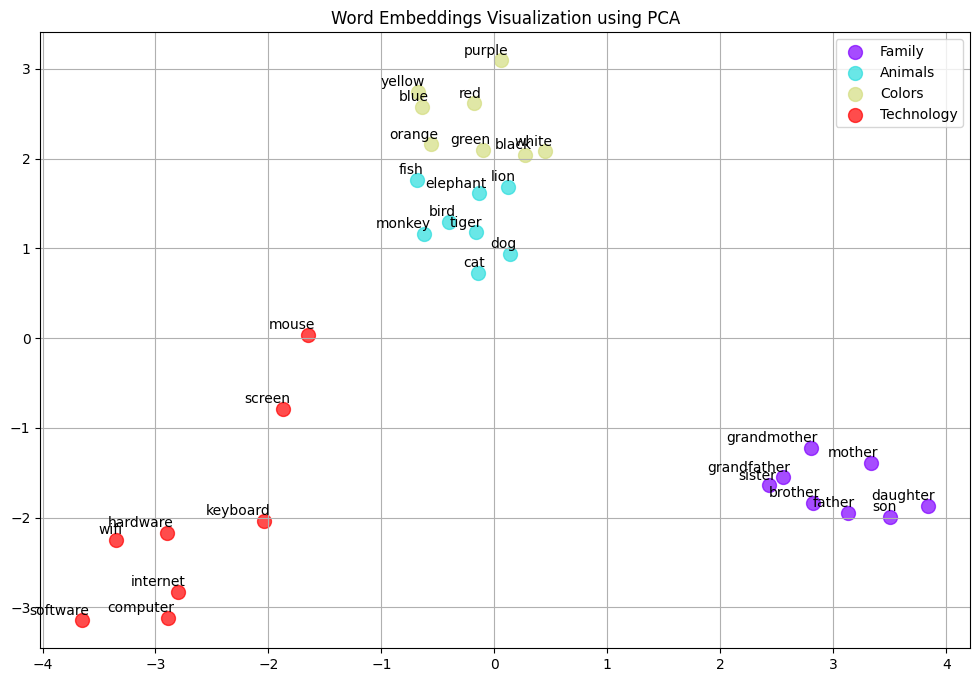

In [9]:
def plot_embeddings(vectors_2d, words, labels, title):
    plt.figure(figsize=(12, 8))
    
    # Tạo màu cho từng nhóm
    unique_labels = list(set(labels))
    colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_labels)))
    
    for i, group_label in enumerate(unique_labels):
        # Lấy index của các từ thuộc nhóm này
        idxs = [j for j, label in enumerate(labels) if label == group_label]
        
        # Vẽ điểm scatter
        plt.scatter(vectors_2d[idxs, 0], vectors_2d[idxs, 1], 
                    c=[colors[i]], label=group_label, s=100, alpha=0.7)
        
        # Gán nhãn tên từ lên biểu đồ
        for idx in idxs:
            plt.annotate(words[idx], 
                         xy=(vectors_2d[idx, 0], vectors_2d[idx, 1]),
                         xytext=(5, 2),
                         textcoords='offset points',
                         ha='right',
                         va='bottom')
            
    plt.legend(loc='best')
    plt.title(title)
    plt.grid(True)
    plt.show()

# --- Thực hiện PCA ---
pca = PCA(n_components=2)
vectors_pca = pca.fit_transform(all_vectors)

# Vẽ biểu đồ
plot_embeddings(vectors_pca, all_words, labels, "Word Embeddings Visualization using PCA")

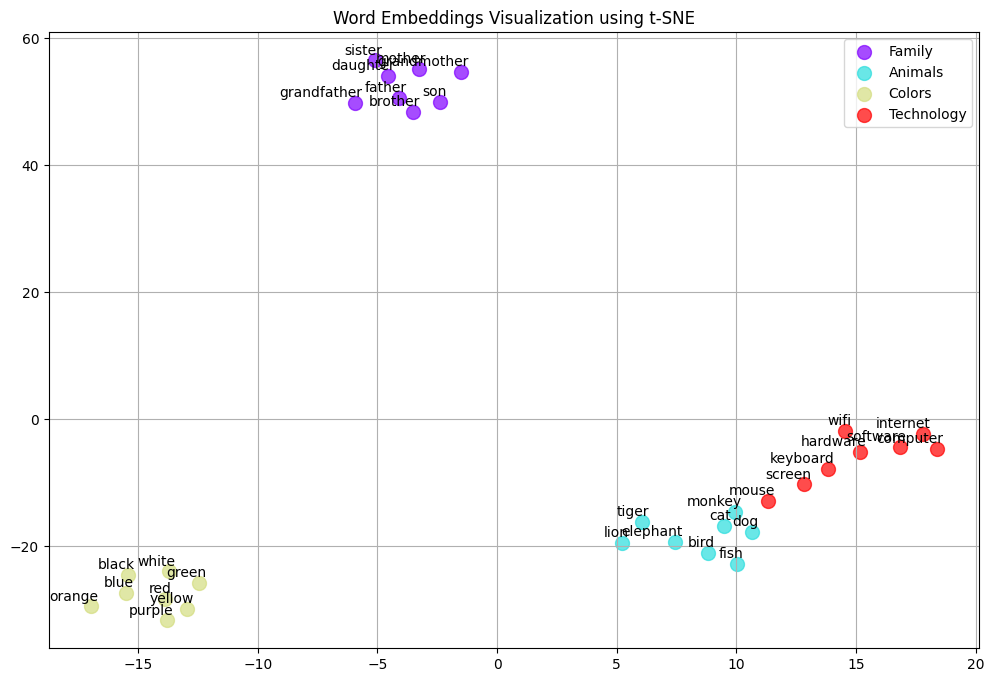

In [5]:
# Perplexity nên nhỏ hơn số lượng điểm dữ liệu (thường từ 5-50). 
# Vì tập data demo nhỏ (32 từ), ta chọn perplexity thấp (ví dụ: 5 hoặc 10).
tsne = TSNE(n_components=2, perplexity=5, random_state=42, init='pca', learning_rate='auto')
vectors_tsne = tsne.fit_transform(all_vectors)

# Vẽ biểu đồ
plot_embeddings(vectors_tsne, all_words, labels, "Word Embeddings Visualization using t-SNE")